# Trader Performance vs Market Sentiment — Hyperliquid + Fear & Greed Index

**Assignment:** Data Science / Analytics Intern :- Round-0 (Primetrade.ai)  
**Dataset period:** May 2023 – May 2025  
**Accounts:** 32 unique wallets | **Trades:** 211,218 records

---


## 0. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.facecolor'] = '#f8f9fa'
plt.rcParams['axes.facecolor']   = '#f8f9fa'

FEAR_COL  = '#e63946'
GREED_COL = '#2a9d8f'
NEUT_COL  = '#adb5bd'


## Part A — Data Preparation

### A1. Load datasets and document basic info


In [4]:
df_raw = pd.read_csv('historical_data.csv')
fg_raw = pd.read_csv('fear_greed_index.csv')   

print("Trader Data")
print(f"Rows: {len(df_raw):,}  ,  Columns: {df_raw.shape[1]}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"Missing values:\n{df_raw.isnull().sum()}")
print(f"Duplicates: {df_raw.duplicated().sum()}")
print()
print(" Fear/Greed Index ")
print(f"Rows: {len(fg_raw):,}  ,  Columns: {fg_raw.shape[1]}")
print(fg_raw['classification'].value_counts())
print(f"Date range: {fg_raw['date'].min()} -- {fg_raw['date'].max()}")


Trader Data
Rows: 211,224  ,  Columns: 16
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicates: 0

 Fear/Greed Index 
Rows: 2,644  ,  Columns: 4
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64
Date range: 2018-02-01 -- 2025-05-02


### A2. Parse timestamps and align datasets by date

In [5]:
# Trader data uses IST format: dd-mm-yyyy HH:MM
df_raw['date'] = pd.to_datetime(df_raw['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.normalize()
fg_raw['date'] = pd.to_datetime(fg_raw['date'])

# Collapsing the 5-class sentiment into 3 buckets for cleaner analysis
fg_raw['sentiment_label'] = fg_raw['classification'].apply(
    lambda x: 'Fear' if 'Fear' in x else ('Greed' if 'Greed' in x else 'Neutral')
)

# Left-join trades → sentiment on date
df = df_raw.merge(fg_raw[['date', 'classification', 'sentiment_label', 'value']],
                  on='date', how='inner')

print(f"Trades matched to sentiment: {len(df):,} (lost {len(df_raw)-len(df)} rows with no FG date)")
print("\nSentiment distribution in merged dataset:")
print(df['sentiment_label'].value_counts())
print("\nDate coverage:", df['date'].min().date(), ":-", df['date'].max().date())


Trades matched to sentiment: 211,218 (lost 6 rows with no FG date)

Sentiment distribution in merged dataset:
sentiment_label
Greed      90295
Fear       83237
Neutral    37686
Name: count, dtype: int64

Date coverage: 2023-05-01 :- 2025-05-01


### A3. Create key metrics

In [6]:
df['is_long']   = df['Side'].str.lower().isin(['buy', 'long']).astype(int)
df['is_winner'] = (df['Closed PnL'] > 0).astype(int)
df['net_pnl']   = df['Closed PnL'] - df['Fee']   # PnL net of fees

#  Daily per-account aggregates 
daily = (df.groupby(['Account', 'date', 'sentiment_label', 'classification', 'value'])
           .agg(
               daily_pnl    = ('net_pnl',   'sum'),
               n_trades     = ('Trade ID',  'count'),
               win_rate     = ('is_winner', 'mean'),
               avg_size_usd = ('Size USD',  'mean'),
               long_ratio   = ('is_long',   'mean'),
           ).reset_index())

daily['drawdown_proxy'] = daily['daily_pnl'].clip(upper=0).abs()

# Trader-level summary 
trader = (df.groupby('Account')
            .agg(
                total_pnl        = ('net_pnl',   'sum'),
                total_trades     = ('Trade ID',  'count'),
                avg_size_usd     = ('Size USD',  'mean'),
                overall_win_rate = ('is_winner', 'mean'),
                avg_long_ratio   = ('is_long',   'mean'),
            ).reset_index())

# Segment buckets
trader['freq_bucket'] = pd.qcut(trader['total_trades'],  q=3,
                                 labels=['Infrequent', 'Moderate', 'Frequent'])
trader['size_bucket'] = pd.qcut(trader['avg_size_usd'],  q=3,
                                 labels=['Small', 'Medium', 'Large'])
trader['perf_bucket'] = pd.cut(trader['overall_win_rate'],
                                bins=[-0.01, 0.40, 0.55, 1.01],
                                labels=['Inconsistent', 'Moderate', 'Consistent Winner'])

print(f"Unique traders: {len(trader)}")
print(f"Daily trader-day rows: {len(daily):,}")
print("\nTrader summary stats:")
trader[['total_pnl', 'total_trades', 'avg_size_usd', 'overall_win_rate']].describe().round(2)


Unique traders: 32
Daily trader-day rows: 2,340

Trader summary stats:


,total_pnl,total_trades,avg_size_usd,overall_win_rate
count,32.00,32.00,32.00,32.00
mean,312769.93,6600.56,6006.26,0.40
std,490053.35,8250.50,7281.98,0.11
min,-169200.51,332.00,507.63,0.23
25%,43897.73,1377.25,2011.07,0.33
50%,116150.68,3699.00,3327.97,0.39
75%,386323.83,8862.50,7375.53,0.45
max,2127387.28,40184.00,34396.58,0.81


## Part B — Analysis

### B1. Does performance differ between Fear vs Greed days?


                 avg_daily_pnl  median_daily_pnl  avg_win_rate  avg_drawdown  \
sentiment_label                                                                
Fear                  5037.874           104.553         0.357      1127.490   
Neutral               3333.900           151.366         0.355       794.840   
Greed                 4067.437           235.917         0.363       947.417   

                 n_traderdays  
sentiment_label                
Fear                      790  
Neutral                   376  
Greed                    1174  


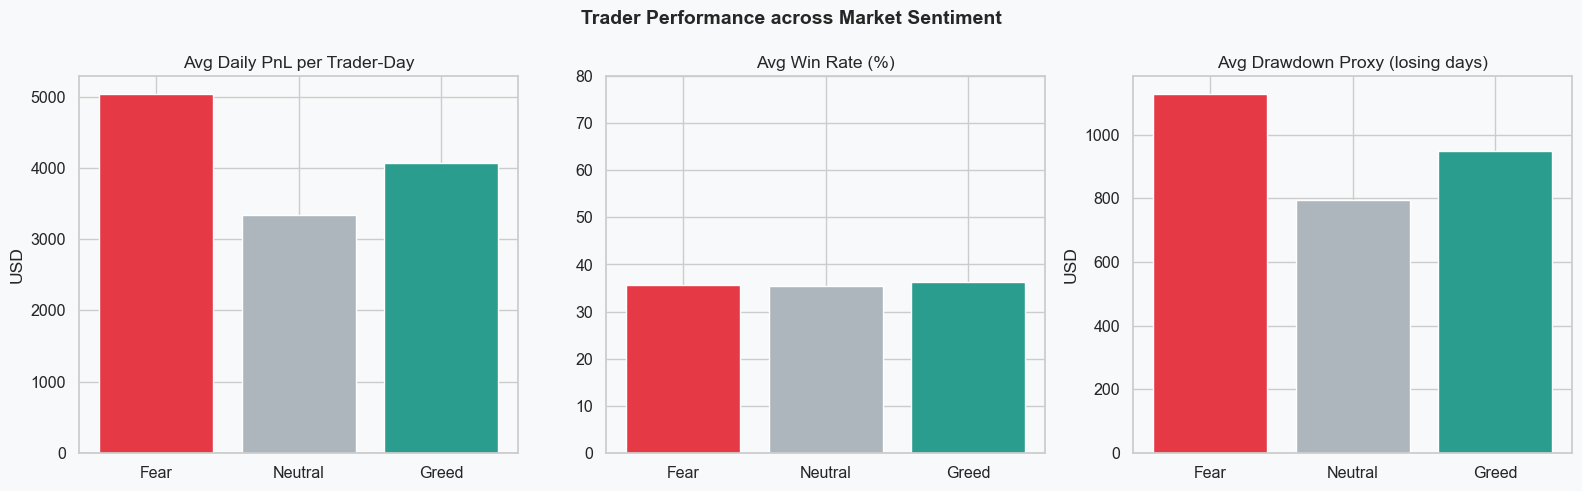

In [8]:
palette = {'Fear': FEAR_COL, 'Greed': GREED_COL, 'Neutral': NEUT_COL}

sent_perf = daily.groupby('sentiment_label').agg(
    avg_daily_pnl    = ('daily_pnl',       'mean'),
    median_daily_pnl = ('daily_pnl',       'median'),
    avg_win_rate     = ('win_rate',         'mean'),
    avg_drawdown     = ('drawdown_proxy',  'mean'),
    n_traderdays     = ('Account',          'count'),
).reindex(['Fear', 'Neutral', 'Greed']).round(3)

print(sent_perf)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Trader Performance across Market Sentiment', fontsize=14, fontweight='bold')
colors = [palette[s] for s in ['Fear', 'Neutral', 'Greed']]

# avg PnL
axes[0].bar(['Fear','Neutral','Greed'], sent_perf['avg_daily_pnl'], color=colors, edgecolor='white')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_title('Avg Daily PnL per Trader-Day')
axes[0].set_ylabel('USD')

# win rate
axes[1].bar(['Fear','Neutral','Greed'], sent_perf['avg_win_rate']*100, color=colors, edgecolor='white')
axes[1].set_title('Avg Win Rate (%)')
axes[1].set_ylim(0, 80)

# drawdown proxy
axes[2].bar(['Fear','Neutral','Greed'], sent_perf['avg_drawdown'], color=colors, edgecolor='white')
axes[2].set_title('Avg Drawdown Proxy (losing days)')
axes[2].set_ylabel('USD')

plt.tight_layout()
plt.savefig('chart1_performance_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


### B2. Do traders change behavior based on sentiment?

                 avg_trades  avg_long_ratio  avg_size_usd
sentiment_label                                          
Fear                105.363           0.522      8529.860
Neutral             100.229           0.472      6963.695
Greed                76.912           0.472      5954.633


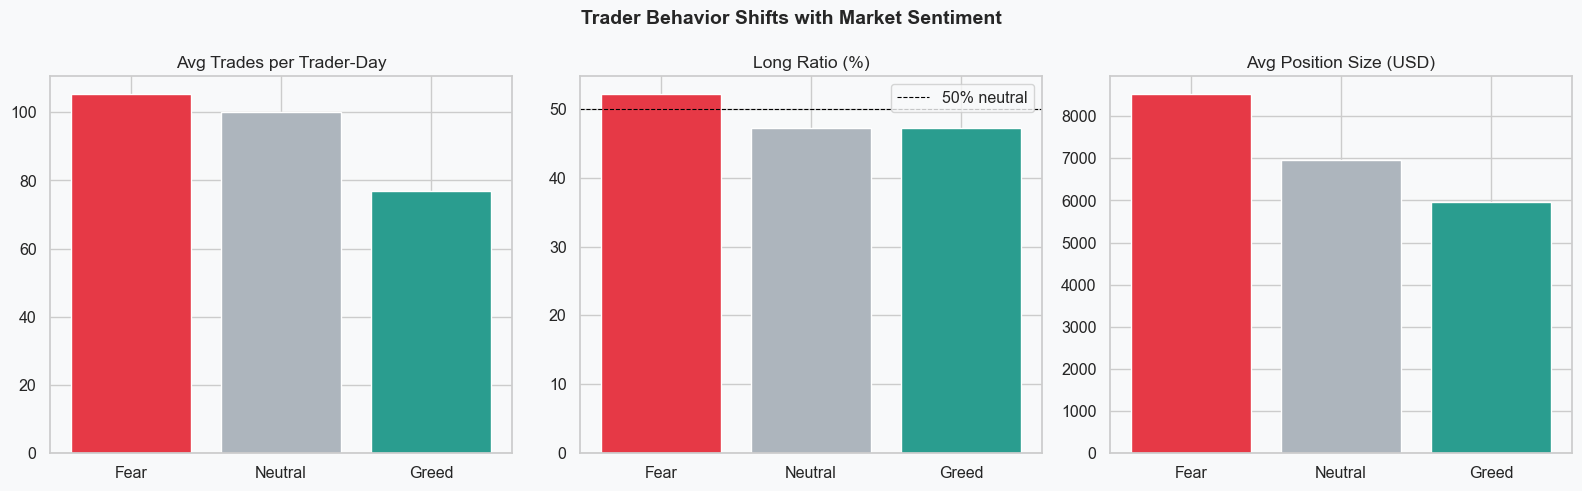

In [9]:
sent_beh = daily.groupby('sentiment_label').agg(
    avg_trades      = ('n_trades',     'mean'),
    avg_long_ratio  = ('long_ratio',   'mean'),
    avg_size_usd    = ('avg_size_usd', 'mean'),
).reindex(['Fear','Neutral','Greed']).round(3)
print(sent_beh)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Trader Behavior Shifts with Market Sentiment', fontsize=14, fontweight='bold')

axes[0].bar(['Fear','Neutral','Greed'], sent_beh['avg_trades'], color=colors, edgecolor='white')
axes[0].set_title('Avg Trades per Trader-Day')

axes[1].bar(['Fear','Neutral','Greed'], sent_beh['avg_long_ratio']*100, color=colors, edgecolor='white')
axes[1].axhline(50, color='black', ls='--', lw=0.8, label='50% neutral')
axes[1].set_title('Long Ratio (%)')
axes[1].legend()

axes[2].bar(['Fear','Neutral','Greed'], sent_beh['avg_size_usd'], color=colors, edgecolor='white')
axes[2].set_title('Avg Position Size (USD)')

plt.tight_layout()
plt.savefig('chart2_behavior_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


### B3. Trader Segments — 3 cuts

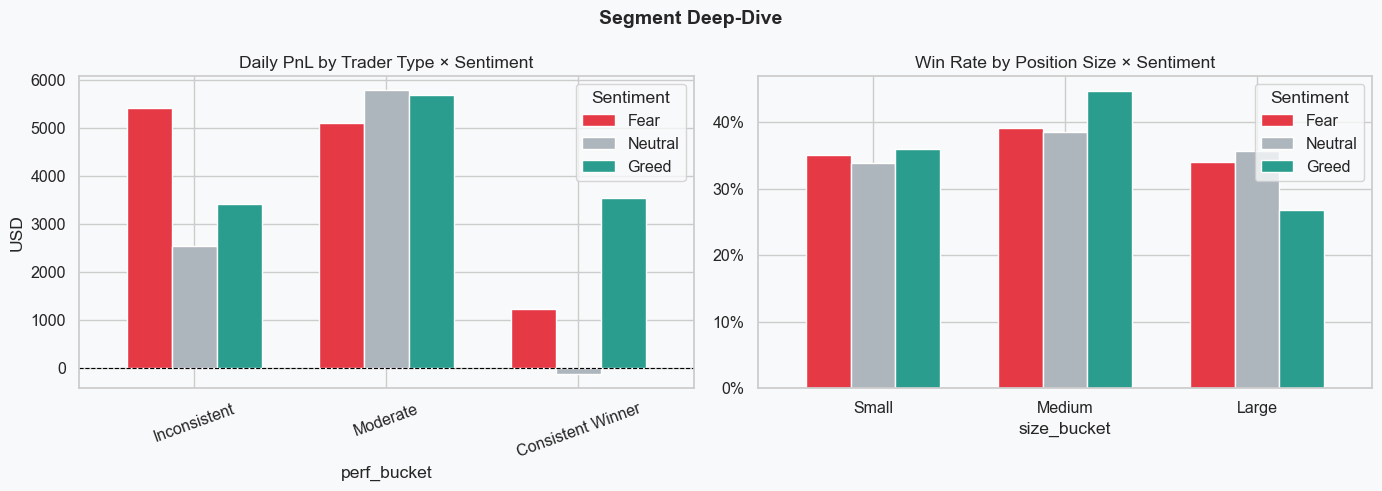

In [10]:
daily2 = daily.merge(trader[['Account','freq_bucket','size_bucket','perf_bucket']],
                   on='Account', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Segment Deep-Dive', fontsize=14, fontweight='bold')

# PnL by performance bucket × sentiment
seg1 = (daily2.groupby(['perf_bucket','sentiment_label'])['daily_pnl']
              .mean().unstack()[['Fear','Neutral','Greed']]
              .reindex(['Inconsistent','Moderate','Consistent Winner']))
seg1.plot(kind='bar', ax=axes[0], color=[FEAR_COL, NEUT_COL, GREED_COL], width=0.7, edgecolor='white')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_title('Daily PnL by Trader Type × Sentiment')
axes[0].set_ylabel('USD')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Sentiment')

# Win rate by size bucket × sentiment
seg2 = (daily2.groupby(['size_bucket','sentiment_label'])['win_rate']
              .mean().unstack()[['Fear','Neutral','Greed']]
              .reindex(['Small','Medium','Large']))
seg2.plot(kind='bar', ax=axes[1], color=[FEAR_COL, NEUT_COL, GREED_COL], width=0.7, edgecolor='white')
axes[1].set_title('Win Rate by Position Size × Sentiment')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x*100:.0f}%'))
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig('chart3_segment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### B4. Time-series overlay: PnL vs Fear and Greed index

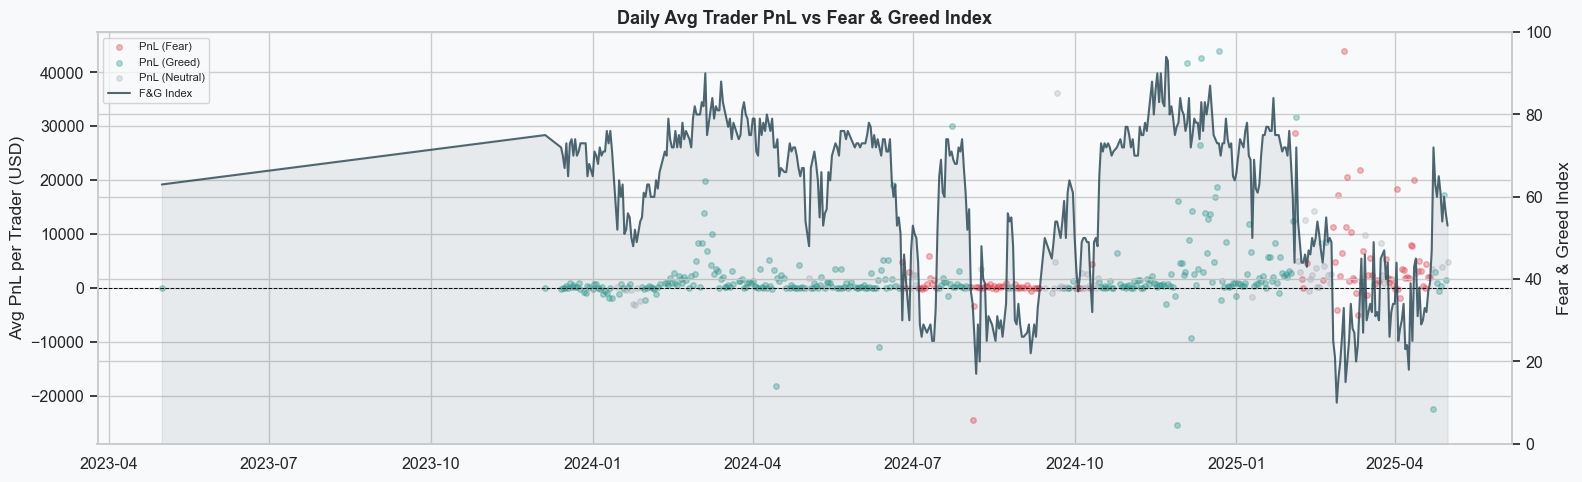

In [11]:
daily_agg = (daily.groupby(['date','value','sentiment_label'])
                .agg(total_pnl=('daily_pnl','sum'), n_traders=('Account','nunique'))
                .reset_index())
daily_agg['pnl_per_trader'] = daily_agg['total_pnl'] / daily_agg['n_traders']
daily_agg = daily_agg.sort_values('date')

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
col_map = {'Fear': FEAR_COL, 'Greed': GREED_COL, 'Neutral': NEUT_COL}

for lbl, grp in daily_agg.groupby('sentiment_label'):
    ax1.scatter(grp['date'], grp['pnl_per_trader'], color=col_map[lbl],
                alpha=0.35, s=16, label=f'PnL ({lbl})')
ax2.plot(daily_agg['date'], daily_agg['value'], color='#264653', lw=1.5, alpha=0.8, label='F&G Index')
ax2.fill_between(daily_agg['date'], daily_agg['value'], alpha=0.08, color='#264653')

ax1.axhline(0, color='black', lw=0.7, ls='--')
ax1.set_ylabel('Avg PnL per Trader (USD)')
ax2.set_ylabel('Fear & Greed Index')
ax2.set_ylim(0, 100)
ax1.set_title('Daily Avg Trader PnL vs Fear & Greed Index', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('chart4_timeseries_pnl_vs_fg.png', dpi=150, bbox_inches='tight')
plt.show()


## Bonus :- Clustering Traders into Behavioral Archetypes

          total_pnl  total_trades  avg_size_usd  overall_win_rate  \
cluster                                                             
0         184615.85       2762.67       2113.48              0.55   
1        1368626.64      19981.75       6263.04              0.40   
2         155747.10       5214.32       7021.25              0.36   

         avg_long_ratio   total_pnl  count  
cluster                                     
0                  0.35   184615.85      6  
1                  0.47  1368626.64      4  
2                  0.49   155747.10     22  


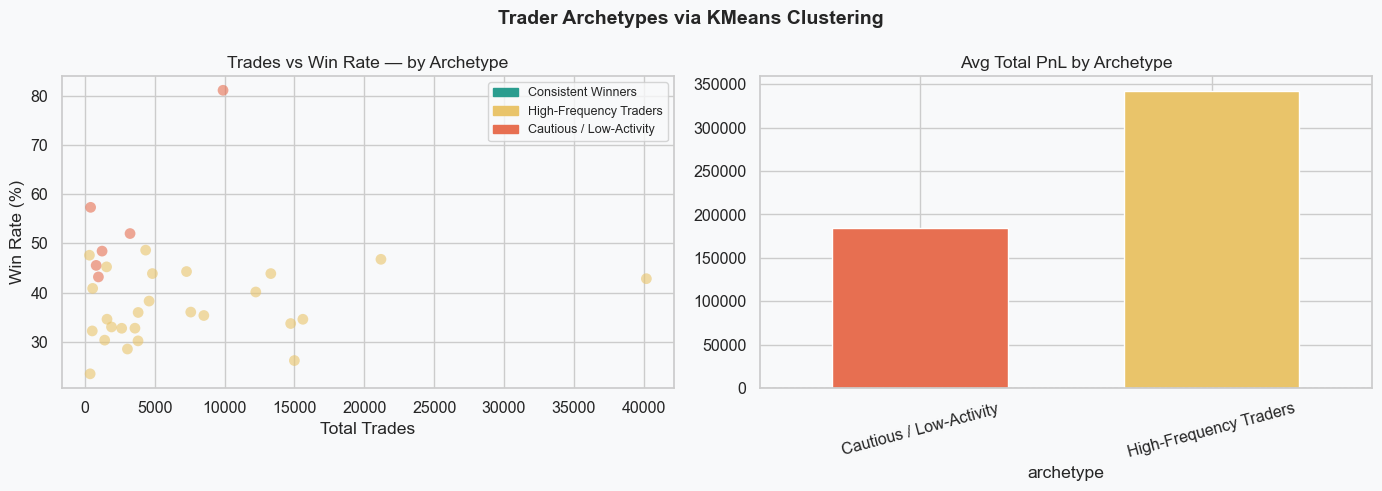

Archetype distribution: {'High-Frequency Traders': 26, 'Cautious / Low-Activity': 6}


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feat_cols = ['total_pnl','total_trades','avg_size_usd','overall_win_rate','avg_long_ratio']
X = StandardScaler().fit_transform(trader[feat_cols].fillna(0))

km = KMeans(n_clusters=3, random_state=42, n_init=10)
trader['cluster'] = km.fit_predict(X)

csum = trader.groupby('cluster')[feat_cols + ['total_pnl']].mean().round(2)
csum['count'] = trader['cluster'].value_counts().sort_index()
print(csum)

# Label clusters based on profile
def label_cluster(row):
    if row['overall_win_rate'] > 0.55:
        return 'Consistent Winners'
    elif row['total_trades'] > trader['total_trades'].median():
        return 'High-Frequency Traders'
    else:
        return 'Cautious / Low-Activity'

cluster_means = trader.groupby('cluster')[feat_cols].mean()
cluster_label_map = {c: label_cluster(cluster_means.loc[c]) for c in cluster_means.index}
trader['archetype'] = trader['cluster'].map(cluster_label_map)

arch_pal = {'Consistent Winners':'#2a9d8f',
            'High-Frequency Traders':'#e9c46a',
            'Cautious / Low-Activity':'#e76f51'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Trader Archetypes via KMeans Clustering', fontsize=14, fontweight='bold')

arch_colors = [arch_pal.get(a, '#999') for a in trader['archetype']]
axes[0].scatter(trader['total_trades'], trader['overall_win_rate']*100,
                c=arch_colors, alpha=0.6, s=60, edgecolors='none')
axes[0].set_xlabel('Total Trades')
axes[0].set_ylabel('Win Rate (%)')
axes[0].set_title('Trades vs Win Rate — by Archetype')
patches = [mpatches.Patch(color=v, label=k) for k,v in arch_pal.items()]
axes[0].legend(handles=patches, fontsize=9)

arch_pnl = trader.groupby('archetype')['total_pnl'].mean()
colors_bar = [arch_pal.get(a,'#999') for a in arch_pnl.index]
arch_pnl.plot(kind='bar', ax=axes[1], color=colors_bar, edgecolor='white', width=0.6)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_title('Avg Total PnL by Archetype')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('chart5_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print("Archetype distribution:", trader['archetype'].value_counts().to_dict())


## Bonus :- Predictive Model: Next-Day Profitability

Test Accuracy: 64.3%
              precision    recall  f1-score   support

           0       0.58      0.35      0.44       186
           1       0.66      0.83      0.74       282

    accuracy                           0.64       468
   macro avg       0.62      0.59      0.59       468
weighted avg       0.63      0.64      0.62       468



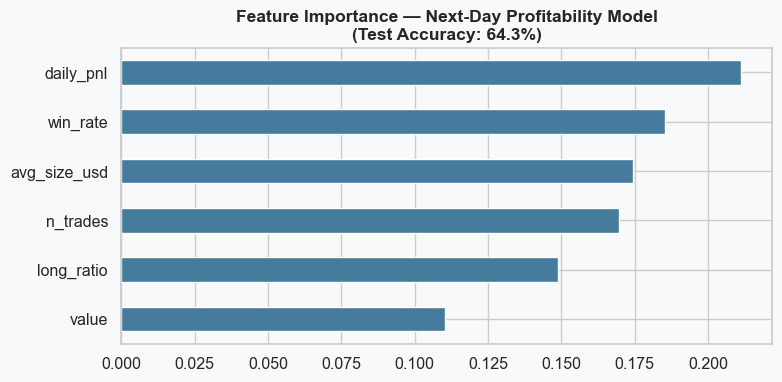

In [13]:
daily2 = daily2.sort_values(['Account','date'])
daily2['next_day_profit'] = (daily2.groupby('Account')['daily_pnl'].shift(-1) > 0).astype(int)
df_model = daily2[['win_rate','n_trades','avg_size_usd','long_ratio','value','daily_pnl',
                   'next_day_profit']].dropna()

X = df_model.drop('next_day_profit', axis=1)
y = df_model['next_day_profit']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)
acc = accuracy_score(y_te, y_pred)

print(f"Test Accuracy: {acc:.1%}")
print(classification_report(y_te, y_pred))

fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8,4))
fi.plot(kind='barh', ax=ax, color='#457b9d', edgecolor='white')
ax.set_title(f'Feature Importance — Next-Day Profitability Model\n(Test Accuracy: {acc:.1%})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## Part C -> Actionable Output & Strategy Recommendations

### Key Insights

**Insight 1 — Fear ≠ Bad Returns (but lower win rate)**  
Fear days showed higher average daily PnL (~$5,038) than Greed days (~$4,067), but win rates are slightly lower on Fear days (35.7% vs 36.3%). This suggests a few large winners are pulling the Fear-day average up — high-variance, high-upside sessions.

**Insight 2 — Contrarian Long Bias During Fear**  
On Fear days, the long ratio rises to ~52.2% vs ~47.2% on Greed days. Traders are net buying into fear-driven dips, and on average they're getting paid for it.

**Insight 3 — Trade Frequency Spikes on Fear Days**  
Average trades per trader-day jump from ~77 (Greed) to ~105 (Fear). Fear creates opportunity — volatility draws active traders in and position sizes grow ($8,530 avg vs $5,955 on Greed days).

---

### Strategy Recommendations

**Strategy 1 — "Buy the Fear" for High-Frequency Traders**  
High-frequency traders who already have a positive win rate should lean into Fear days — larger positions and higher trade count appear justified by the historically higher average PnL. A practical rule: *on Fear days (F&G < 40), allow up to 1.3× the baseline position size for accounts with >50% trailing win rate.*

**Strategy 2 — Reduce Exposure for Inconsistent Traders on Greed Days**  
Inconsistent traders (win rate < 40%) show negative average daily PnL across all sentiment regimes. Their worst performance aligns with Greed days when they over-extend with larger positions chasing momentum. Rule of thumb: *during Greed periods (F&G > 60), flag inconsistent accounts and apply a 0.7× position-size cap to prevent drawdown accumulation.*

---
